# Retrieval-Augmented Generation (RAG): Enhancing LLMs for Business

## What is RAG?
A hybrid AI framework that combines:

- Retrieval: Fetching real-time, relevant data from external sources (e.g., databases, documents).

- Generation: Using LLMs to produce context-aware, accurate responses.

## Key LLM Problems RAG Solves

1. Outdated Knowledge: Overcomes static training data by integrating live/updated information.

2. Hallucinations: Reduces factual inaccuracies by grounding responses in retrieved evidence.

3. Domain Gaps: Accesses proprietary or specialized data (e.g., internal docs, research) for tailored outputs.

## Business Applications

- Customer Support: Accurate, up-to-date answers using internal knowledge bases.

- Healthcare: Real-time access to medical research for diagnostics or patient care.

- Finance: Market analysis with live data for insights or risk assessments.

- Legal: Rapid document review and compliance checks.

- E-commerce: Personalized recommendations using customer/data trends.

- Content Creation: Fact-checked, context-rich content generation.

**Why It Matters**: Drives efficiency, accuracy, and scalability while minimizing LLM limitations.

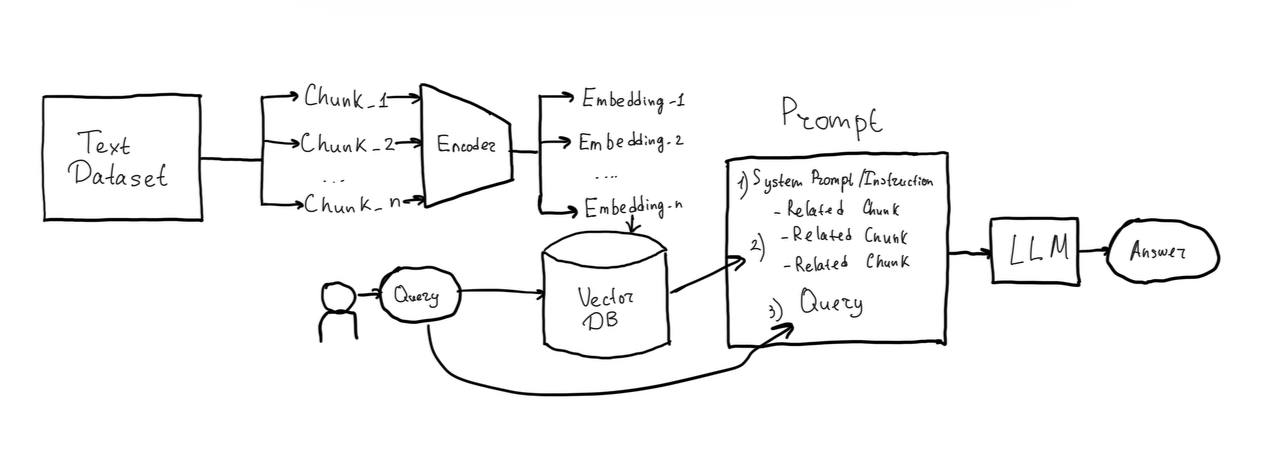


## Installation of Required Libraries

In this tutorial, we will need several tools:
- `langchain-classic`, `langchain-community`, `langchain-core`, `langchain-huggingface`, `langchain-gigachat`, and `langchain-text-splitters` - the current LangChain package split used throughout this seminar;
- `faiss-cpu` - we use the FAISS vector store to store chunks (text fragments for context) and embeddings (vector representations) of these chunks;
- `sentence-transformers` - a library for local use of embedding models from the Hugging Face resource;
- `rank_bm25` - a library for working with BM25 vectorization algorithms (a variation of TF-IDF);
- `playwright` - a library for browser automation, in our case, for parsing a list of articles from a website.


In [ ]:
%pip install -qU langchain-classic==1.0.3 langchain-community==0.4.1 langchain-core==1.2.26 langchain-huggingface==1.2.1 langchain-gigachat==0.5.0 langchain-text-splitters==1.1.1 gigachat==0.2.0 faiss-cpu sentence-transformers rank_bm25 beautifulsoup4 requests pandas pypdf==6.9.2 playwright==1.58.0 python-dotenv


We will also install a browser to collect a list of articles.

In [ ]:
!playwright install chromium


In [ ]:
%pip install -qU unstructured[all-docs] pdfminer.six pi_heif


## Collecting papers

As a source of knowledge, we will use articles from the science website [Pubmed](https://pubmed.ncbi.nlm.nih.gov/). We will take the latest articles on astronautics.

We will use `AsyncChromiumLoader` from GigaChain to load the page. This tool is necessary because the list of articles by category is loaded dynamically, meaning it cannot be retrieved with a simple `requests.get()` call.

Due to the asynchronous nature of `AsyncChromiumLoader`, we will create a separate script for collecting articles.

As a result of running the script, we will obtain a separate text file containing links to articles on space-related topics.

In [ ]:
%%writefile parser.py


import asyncio
from langchain_community.document_loaders import AsyncChromiumLoader
from bs4 import BeautifulSoup

async def fetch_articles():
    url = "https://pubmed.ncbi.nlm.nih.gov/?term=genai"
    loader = AsyncChromiumLoader([url])
    html = await loader.aload()

    with open('page.html', 'w', encoding='utf-8') as f:
        f.write(html[0].page_content)

    soup = BeautifulSoup(html[0].page_content, 'html.parser')
    links = []

    with open('links.txt', 'w', encoding='utf-8') as f:
        for link in soup.find_all('a', class_='docsum-title'):
            href = "https://pubmed.ncbi.nlm.nih.gov" + link['href']
            links.append(href)
            f.write(href + '\n')

    print(f"Extracted {len(links)} article links.")

# Run the async function
asyncio.run(fetch_articles())

Writing parser.py


In [ ]:
# beautifulsoup4 is installed in the main setup cell above.


In [80]:
!python parser.py

USER_AGENT environment variable not set, consider setting it to identify your requests.
Extracted 10 article links.


## Parsing

In [13]:

with open('links.txt') as f:
  sources = f.read()

print(sources.split())


['https://pubmed.ncbi.nlm.nih.gov/38302101/', 'https://pubmed.ncbi.nlm.nih.gov/39322420/', 'https://pubmed.ncbi.nlm.nih.gov/40135733/', 'https://pubmed.ncbi.nlm.nih.gov/41053447/', 'https://pubmed.ncbi.nlm.nih.gov/39903463/', 'https://pubmed.ncbi.nlm.nih.gov/39836377/', 'https://pubmed.ncbi.nlm.nih.gov/39708405/', 'https://pubmed.ncbi.nlm.nih.gov/39587942/', 'https://pubmed.ncbi.nlm.nih.gov/40043704/', 'https://pubmed.ncbi.nlm.nih.gov/39523628/']


In [14]:
sources = 'https://www.nature.com/articles/s41586-024-08252-9 https://www.nature.com/articles/s41612-023-00512-1'

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document


In [ ]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter


Load the Web-site by links using specific loader.

In [17]:
sources.split()

['https://www.nature.com/articles/s41586-024-08252-9',
 'https://www.nature.com/articles/s41612-023-00512-1']

In [18]:
# User-Agent и таймаут помогают избежать SSLError при обращении к nature.com
loader = WebBaseLoader(
    sources.split(),
    requests_kwargs={
        "headers": {
            "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
            "Accept-Language": "en-US,en;q=0.9",
        },
        "timeout": 30,
    }
)

In [20]:
# Повторные попытки при временных SSL/сетевых ошибках
from requests.exceptions import SSLError
max_attempts = 3
for attempt in range(max_attempts):
    try:
        docs = loader.load()
        break
    except SSLError as e:
        if attempt == max_attempts - 1:
            raise
        import time
        time.sleep(2 ** attempt)  # 1s, 2s
docs

[Document(metadata={'source': 'https://www.nature.com/articles/s41586-024-08252-9', 'title': 'Probabilistic weather forecasting with machine learning | Nature', 'description': 'Weather forecasts are fundamentally uncertain, so predicting the range of probable weather scenarios is crucial for important decisions, from warning the public about hazardous weather to planning renewable energy use. Traditionally, weather forecasts have been based on numerical weather prediction (NWP)1, which relies on physics-based simulations of the atmosphere. Recent advances in machine learning (ML)-based weather prediction (MLWP) have produced ML-based models with less forecast error than single NWP simulations2,3. However, these advances have focused primarily on single, deterministic forecasts that fail to represent uncertainty and estimate risk. Overall, MLWP has remained less accurate and reliable than state-of-the-art NWP ensemble forecasts. Here we introduce GenCast, a probabilistic weather model w

In [21]:
docs[0].page_content

"\n\n\nProbabilistic weather forecasting with machine learning | Nature\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSkip to main content\n\n\nThank you for visiting nature.com. You are using a browser version with limited support for CSS. To obtain\n            the best experience, we recommend you use a more up to date browser (or turn off compatibility mode in\n            Internet Explorer). In the meantime, to ensure continued support, we are displaying the site without styles\n            and JavaScript.\n\n\n\n\n\nAdvertisement\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nView all journals\n\n\n\n\nSea

Divide our papers on chunks with length **500** symbols and with **100** symbols overlap.

In [22]:
len(docs)

2

In [23]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=750,
                                              chunk_overlap=150)
split_docs = text_splitter.split_documents(docs)

In [24]:
len(split_docs)

286

In [25]:
split_docs[10].page_content

'which generate several NWP-based forecasts, each of which models a single possible scenario4,8,9,10,11. ENS of the European Centre for Medium-Range Weather Forecasting (ECMWF)4 is the state-of-the-art NWP-based ensemble forecast in the broader Integrated Forecast System of\xa0the ECMWF and will subsume their deterministic forecast, HRES, going forward12.ENS satisfies several key desiderata of a probabilistic weather model. First, its ensemble members represent sharp and spectrally realistic individual weather trajectories, as opposed to some summary statistic such as a conditional mean. Second, it produces skilful and calibrated marginal forecast distributions (forecasts of the weather at a given place and time), which is important for many'

In [ ]:
# %%time
model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': False}
embedding = HuggingFaceEmbeddings(model_name=model_name,
                                  model_kwargs=model_kwargs,
                                  encode_kwargs=encode_kwargs)

vector_store = FAISS.from_documents(split_docs, embedding=embedding)

Let's extract only 5 chunks from our vector DB

In [27]:
vector_store.similarity_search('Tell me about the Fyxi types')

[Document(metadata={'source': 'https://www.nature.com/articles/s41612-023-00512-1', 'title': 'FuXi: a cascade machine learning forecasting system for 15-day global weather forecast | npj Climate and Atmospheric Science', 'description': 'Over the past few years, the rapid development of machine learning (ML) models for weather forecasting has led to state-of-the-art ML models that have superior performance compared to the European Centre for Medium-Range Weather Forecasts (ECMWF)’s high-resolution forecast (HRES), which is widely considered as the world’s best physics-based weather forecasting system. Specifically, ML models have outperformed HRES in 10-day forecasts with a spatial resolution of 0.25∘. However, the challenge remains in mitigating the accumulation of forecast errors for longer effective forecasts, such as achieving comparable performance to the ECMWF ensemble in 15-day forecasts. Despite various efforts to reduce accumulation errors, such as implementing autoregressive m

In [28]:
embedding_retriever = vector_store.as_retriever(search_kwargs={"k": 3})

## Creating the Generative Part of the Pipeline and Building the RAG System Chain

We need to get acess to GigaChat API.



In [1]:
import os
from dotenv import load_dotenv

load_dotenv() 
API_key = os.getenv("API_KEY")

In [ ]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate
from langchain_gigachat.chat_models import GigaChat
from langchain_classic.chains import create_retrieval_chain


In [ ]:
# gigachat is installed in the main setup cell above.


In [6]:
llm = GigaChat(credentials=API_key,
              model='GigaChat:lite',
               verify_ssl_certs=False,
               scope="GIGACHAT_API_PERS",
               profanity_check=False)
prompt = ChatPromptTemplate.from_template('''Answer the user's question. \
Use only the information from the context to do so. If the context does not contain \
enough information to answer, inform the user of this.
Context: {context}
Question: {input}
Answer: '''
)

We will create the `create_stuff_documents_chain`, which will be part of our question-and-answer chain. This is necessary to feed text fragments from the vector database into the language model’s prompt. The prompt is a formatted string, and the fragments are instances of the `Document` class. To avoid writing code to extract the `page_content` attribute from `Document`, we use the `create_stuff_documents_chain`, where this process is automated.

In [ ]:
# Example context and question
context_text = "LangChain is a framework for developing applications powered by language models."
user_question = "What is LangChain?"

# Format the prompt with context and question
formatted_prompt = prompt.format_prompt(context=context_text, input=user_question)

# Get the answer from the LLM
response = llm.invoke(formatted_prompt.to_messages())

# Print the answer
print(response)


In [9]:
# llm

In [10]:
document_chain = create_stuff_documents_chain(
    llm=llm,
    prompt=prompt
    )

And now, let's create the question-and-answer chain using the `create_retrieval_chain()` function.

In [29]:
retrieval_chain = create_retrieval_chain(embedding_retriever, document_chain)

## Let's test our RAG

In [30]:
q1 = 'GenCast outperforms the CRPS of ENS by around...'

In [31]:
resp1 = retrieval_chain.invoke(
    {'input': q1}
)

In [32]:
resp1

{'input': 'GenCast outperforms the CRPS of ENS by around...',
 'context': [Document(metadata={'source': 'https://www.nature.com/articles/s41586-024-08252-9', 'title': 'Probabilistic weather forecasting with machine learning | Nature', 'description': 'Weather forecasts are fundamentally uncertain, so predicting the range of probable weather scenarios is crucial for important decisions, from warning the public about hazardous weather to planning renewable energy use. Traditionally, weather forecasts have been based on numerical weather prediction (NWP)1, which relies on physics-based simulations of the atmosphere. Recent advances in machine learning (ML)-based weather prediction (MLWP) have produced ML-based models with less forecast error than single NWP simulations2,3. However, these advances have focused primarily on single, deterministic forecasts that fail to represent uncertainty and estimate risk. Overall, MLWP has remained less accurate and reliable than state-of-the-art NWP ense

## Using the BM25 Retriever

Now, for the vectorization of fragments and the user's query, we will use a simpler model. The BM25 model is based on TF-IDF vectorization. That is, unlike embedding models where a vector represents a numerical representation of semantic meaning, BM25 vectorizes text based on words. You could say that searching with BM25 is essentially a keyword-based search.

Since BM25 works with words rather than meanings, it is necessary to perform text preprocessing, as in classical NLP, to reduce the vocabulary size.

In [33]:
import string

def tokenize(s):
    return s.lower().translate(str.maketrans("", "", string.punctuation)).split(" ")

In [34]:
bm25_retriever = BM25Retriever.from_documents(
      documents=split_docs,
      preprocess_func=tokenize,
      k=3,
  )

In [35]:
q1 = 'Tell me about different Fuxies models'

In [ ]:
bm25_retriever.invoke(q1)


In [37]:
bm25_chain = create_retrieval_chain(bm25_retriever, document_chain)

In [38]:
resp1_2 = bm25_chain.invoke(
    {'input': q1}
)

In [39]:
resp1_2

{'input': 'Tell me about different Fuxies models',
 'context': [Document(metadata={'source': 'https://www.nature.com/articles/s41612-023-00512-1', 'title': 'FuXi: a cascade machine learning forecasting system for 15-day global weather forecast | npj Climate and Atmospheric Science', 'description': 'Over the past few years, the rapid development of machine learning (ML) models for weather forecasting has led to state-of-the-art ML models that have superior performance compared to the European Centre for Medium-Range Weather Forecasts (ECMWF)’s high-resolution forecast (HRES), which is widely considered as the world’s best physics-based weather forecasting system. Specifically, ML models have outperformed HRES in 10-day forecasts with a spatial resolution of 0.25∘. However, the challenge remains in mitigating the accumulation of forecast errors for longer effective forecasts, such as achieving comparable performance to the ECMWF ensemble in 15-day forecasts. Despite various efforts to re

## Save answers as file

In [40]:
rows = []
results = [
    resp1,
    resp1_2,
]
for data in results:
  for context in data['context']:
    row = {
        'input': data['input'],
        'context': context.page_content,
        'source': context.metadata['source'],
        'title': context.metadata['title'],
        'description': context.metadata['description'],
        'language': context.metadata['language'],
        'answer': data['answer']
    }
    rows.append(row)

In [ ]:
# pandas is installed in the main setup cell above.


In [44]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame(rows)
display(df)

df.to_csv('output.csv', index=False)

,input,context,source,title,description,language,answer
0,GenCast outperforms the CRPS of ENS by around...,pooled verification targets—spanning each vari...,https://www.nature.com/articles/s41586-024-082...,Probabilistic weather forecasting with machine...,"Weather forecasts are fundamentally uncertain,...",en,**Arguments:**\n\n1. **CRPS Performance Compar...
1,GenCast outperforms the CRPS of ENS by around...,"of 120 km, 240 km and 480 km.GenCast outperfor...",https://www.nature.com/articles/s41586-024-082...,Probabilistic weather forecasting with machine...,"Weather forecasts are fundamentally uncertain,...",en,**Arguments:**\n\n1. **CRPS Performance Compar...
2,GenCast outperforms the CRPS of ENS by around...,neither model is significantly better (P > 0.0...,https://www.nature.com/articles/s41586-024-082...,Probabilistic weather forecasting with machine...,"Weather forecasts are fundamentally uncertain,...",en,**Arguments:**\n\n1. **CRPS Performance Compar...
3,Tell me about different Fuxies models,demands of running 51 members with limited com...,https://www.nature.com/articles/s41612-023-005...,FuXi: a cascade machine learning forecasting s...,"Over the past few years, the rapid development...",en,**Arguments:**\n\n1. **FuXi Model Overview:** ...
4,Tell me about different Fuxies models,model that generates global 15-day ensemble fo...,https://www.nature.com/articles/s41586-024-082...,Probabilistic weather forecasting with machine...,"Weather forecasts are fundamentally uncertain,...",en,**Arguments:**\n\n1. **FuXi Model Overview:** ...
5,Tell me about different Fuxies models,FuXiThe FuXi model is an autoregressive model ...,https://www.nature.com/articles/s41612-023-005...,FuXi: a cascade machine learning forecasting s...,"Over the past few years, the rapid development...",en,**Arguments:**\n\n1. **FuXi Model Overview:** ...


## Question-Answer System with Two Retrievers
We will create a hybrid system where two out of five fragments will be retrieved using embeddings, and the other three will be retrieved using vectors obtained through the BM25 model.

In [45]:
embedding_retriever = vector_store.as_retriever(search_kwargs={"k": 2})
bm25_retriever = BM25Retriever.from_documents(
    documents=split_docs,
    preprocess_func=tokenize,
    k=3,
)

In [46]:
ensemble_retriever = EnsembleRetriever(
    retrievers=[embedding_retriever, bm25_retriever],
    weights=[0.4, 0.6],
)

In [ ]:
from langchain_classic.chains import RetrievalQA
qa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=ensemble_retriever,
    return_source_documents=True,
)


In [48]:
qa.invoke({"query": q1})

{'query': 'Tell me about different Fuxies models',
 'result': 'There are three distinct FuXi models mentioned:\n\n1. **FuXi-Short**: This model generates 5-day forecasts.\n2. **FuXi-Medium**: This model also generates 5-day forecasts but cascades with other models to contribute to longer-term forecasts.\n3. **FuXi-Long**: This model is part of a cascade setup along with FuXi-Short and FuXi-Medium to create comprehensive 15-day forecasts.\n\nEach of these models uses an autoregressive approach based on past weather parameters to predict future conditions. They utilize a combination of upper-air and surface variables, forming a data cube with specific dimensions (2 × 70 × 721 × 1440).\n\nThese models work together to provide detailed and accurate forecasts across various temporal horizons.',
 'source_documents': [Document(metadata={'source': 'https://www.nature.com/articles/s41612-023-00512-1', 'title': 'FuXi: a cascade machine learning forecasting system for 15-day global weather foreca

In [49]:
qa.invoke({"query": "What is a FuXi model architecture?"})

{'query': 'What is a FuXi model architecture?',
 'result': 'A FuXi model architecture consists of three main components:\n\n1. **Cube Embedding**: This component processes the input data combining both upper-air and surface variables into a data cube.\n   \n2. **U-Transformer**: This is a key component that learns complex relationships from high-dimensional weather data efficiently.\n\n3. **Fully Connected (FC) Layer**: This final layer connects the outputs of the U-Transformer to produce the forecast.\n\nAdditionally, there are cascaded versions of the FuXi model—FuXi-Short, FuXi-Medium, and FuXi-Long—which collectively generate 15-day forecasts by producing 5-day increments using each model.',
 'source_documents': [Document(metadata={'source': 'https://www.nature.com/articles/s41612-023-00512-1', 'title': 'FuXi: a cascade machine learning forecasting system for 15-day global weather forecast | npj Climate and Atmospheric Science', 'description': 'Over the past few years, the rapid de

In [50]:
qa.invoke({"query": "Compare GraphCast and FuXi"})

{'query': 'Compare GraphCast and FuXi',
 'result': "Based on the provided context:\n\nGraphCast and FuXi are both advanced machine learning-based weather forecasting models. They significantly outperform the traditional ECMWF HRES model in terms of forecast accuracy. Here are some key points comparing them:\n\n1. **Performance over Time**:\n   - Both GraphCast and FuXi show comparable performance within forecasts of 7 days.\n   - Beyond this period, FuXi demonstrates superior performance, achieving lower RMSE (Root Mean Square Error) and higher ACC (Accuracy) values across various variables and forecast lead times.\n   \n2. **Lead Time Improvement**:\n   - FuXi's superior performance becomes more pronounced as lead times increase. For example, it extends the skillful forecast lead time for variables like Z500 and T2M compared to ECMWF HRES.\n   - Specifically, FuXi pushes the lead time for Z500 and T2M from 9.25 and 10 days to 10.5 and 14.5 days, respectively.\n\n3. **Comparison Metric

## RAG based documents

We try to use 2 document types:



*   pdf/docx
*  csv/xlsx



In [ ]:
# unstructured and its document parsing extras are installed in the setup cells above.


In [66]:
# !apt-get install -y poppler-utils

# !brew install poppler-qt5

In [54]:
import requests

url = "https://www.geokniga.org/bookfiles/geokniga-fizika-neftegazovyh-plastov-i-nelineynye-yavleniya.pdf"
response = requests.get(url)

with open("book.pdf", "wb") as f:
    f.write(response.content)

In [ ]:
# os.environ["PATH"] = "/opt/homebrew/bin" + os.pathsep + os.environ.get("PATH", "")

from langchain_community.document_loaders import UnstructuredPDFLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=10000,
                                              chunk_overlap=100)
pdf_file = 'book.pdf'
loader = PyPDFLoader(pdf_file)
splitted_data = loader.load_and_split(text_splitter)


In [88]:
url = 'https://raw.githubusercontent.com/blanzh/carsBase/refs/heads/master/cars.csv'
response = requests.get(url)

with open("cars.csv", "wb") as f:
    f.write(response.content)

In [84]:
from langchain_community.document_loaders.csv_loader import CSVLoader

In [85]:
loader = CSVLoader('cars.csv')

In [70]:
table = loader.load()

In [71]:
len(table)

4721

In [72]:
vector_store_csv = FAISS.from_documents(table[:1000], embedding=embedding)

In [73]:
table[100]

Document(metadata={'source': 'cars.csv', 'row': 100}, page_content='ID_MARK: ALPINA\nМарка: Alpina\nМарка кириллица: Альпина\nПопулярная марка: 0\nСтрана: Германия\nГод марки от: 1978\nГод марки до: 2026\nMODEL_ID: ALPINA_B6\nМодель: B6\nМодель кириллица: б6\nКласс: E\nГод модели от: 1978\nГод модели до: 2017')

In [74]:
vector_store_csv.similarity_search('Китайские машины')

[Document(metadata={'source': 'cars.csv', 'row': 674}, page_content='ID_MARK: CHANGFENG\nМарка: Changfeng\nМарка кириллица: Чанфэн\nПопулярная марка: 0\nСтрана: Китай\nГод марки от: 1999\nГод марки до: 2014\nMODEL_ID: CHANGFENG_CS6\nМодель: SUV (CS6)\nМодель кириллица: СУВ\nКласс: J\nГод модели от: 2007\nГод модели до: 2009'),
 Document(metadata={'source': 'cars.csv', 'row': 627}, page_content='ID_MARK: CHANGAN\nМарка: Changan\nМарка кириллица: Чанган\nПопулярная марка: 0\nСтрана: Китай\nГод марки от: 2006\nГод марки до: 2026\nMODEL_ID: CHANGAN_AUCHAN_A600EV\nМодель: Auchan A600 EV\nМодель кириллица: Ашан А600 ЕВ\nКласс: M\nГод модели от: 2018\nГод модели до: 2022'),
 Document(metadata={'source': 'cars.csv', 'row': 640}, page_content='ID_MARK: CHANGAN\nМарка: Changan\nМарка кириллица: Чанган\nПопулярная марка: 0\nСтрана: Китай\nГод марки от: 2006\nГод марки до: 2026\nMODEL_ID: CHANGAN_CS75_PRO\nМодель: CS75 Pro\nМодель кириллица: ЦС75 Про\nКласс: D\nГод модели от: 2025\nГод модели до: 

In [76]:
embedding_retriever = vector_store_csv.as_retriever(search_kwargs={"k": 10})
bm25_retriever = BM25Retriever.from_documents(
    documents=table,
    preprocess_func=tokenize,
    k=3,
)

In [ ]:
from langchain_classic.chains import RetrievalQA
ensemble_retriever = EnsembleRetriever(
    retrievers=[embedding_retriever, bm25_retriever],
    weights=[0.4, 0.6],
)

qa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=ensemble_retriever,
    return_source_documents=True,
)


In [78]:
qa.invoke({'query': 'Call me three name of chinese cars'})

{'query': 'Call me three name of chinese cars',
 'result': 'Three well-known Chinese car brands include:\n\n1. BYD\n2. Chery\n3. Geely',
 'source_documents': [Document(metadata={'source': 'https://www.nature.com/articles/s41612-023-00512-1', 'title': 'FuXi: a cascade machine learning forecasting system for 15-day global weather forecast | npj Climate and Atmospheric Science', 'description': 'Over the past few years, the rapid development of machine learning (ML) models for weather forecasting has led to state-of-the-art ML models that have superior performance compared to the European Centre for Medium-Range Weather Forecasts (ECMWF)’s high-resolution forecast (HRES), which is widely considered as the world’s best physics-based weather forecasting system. Specifically, ML models have outperformed HRES in 10-day forecasts with a spatial resolution of 0.25∘. However, the challenge remains in mitigating the accumulation of forecast errors for longer effective forecasts, such as achieving 